In [ ]:
# SAMPLE DATASET FOR CLUSTERING DEMONSTRATION.
# NumPy is required here for numerical data handling.
import numpy as np
X = np.array([ 
    [1, 2], [2, 1], [3, 4], 
    [5, 7], [6, 8], [7, 6], 
    [8, 5], [4, 3]
])
print(X)


#Visualization before clustering :-
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1])
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.grid(True)
plt.show()

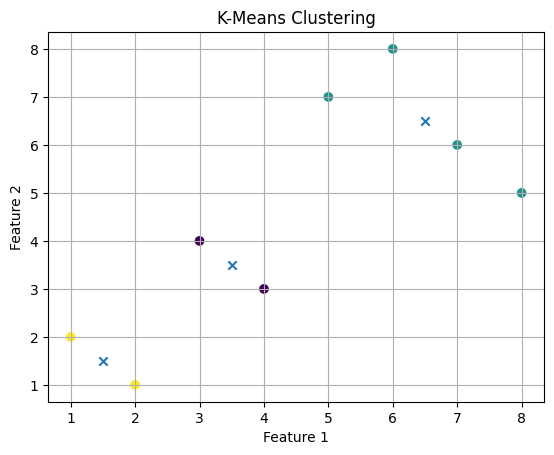

In [8]:
# K-MEANS CLUSTERING
# Scikit-learn KMeans is required here
#scikit learn is python library used for machince learning.

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)  #No of clusters is 3 and random state is used so that after every run the initial centroids remains the same.
labels = kmeans.fit_predict(X)  #Train the model on the dataset X and predict labels for each data point.

plt.scatter(X[:, 0], X[:, 1], c=labels)   #Plotting the data points.
plt.scatter( kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='x')   #Plotting the cluster centroids.
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

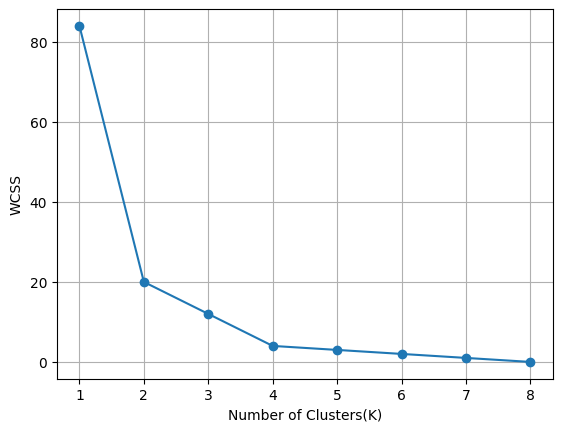

In [12]:
# ELBOW METHOD FOR OPTIMAL K
"""
Elbow Method:
- Plot K vs WCSS
- Elbow point gives optimal K
"""

wcss = []
for k in range(1,9):
    km = KMeans(n_clusters = k, random_state=42)
    km.fit(X)  # train the model for disticnt k values from 1-8
    wcss.append(km.inertia_)  # km.inertia_ returns the wcss value.
    
plt.plot(range(1,9), wcss, marker='o')
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


#IF SOME WARNING OCCURS :-
# Why this warning appears:
# - Scikit-learn uses Intel MKL
# - On Windows, KMeans may create too many threads
# - This causes a harmless memory-leak warning
# - Clustering results (WCSS and elbow plot) remain correct
# Best fix

# Limit the number of threads used by MKL
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [ ]:
# HIERARCHICAL CLUSTERING
# SciPy is required here for hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage

#linkage() → performs hierarchical clustering
# computes distances between points/clusters.
# repeatedly merges nearest clusters.
# stores the entire clustering process.

# Ward method merges clusters such that :-
# increase in variance is minimum
# clusters remain compact
# It tries to minimize :-
# Within Cluster Sum of Squares (WCSS) similar to K Means.
Z = linkage(X, method='ward') 

dendrogram(Z)  #dendrogram() → draws tree diagram

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# Lower merge height → more similar
# Higher merge height → less similar

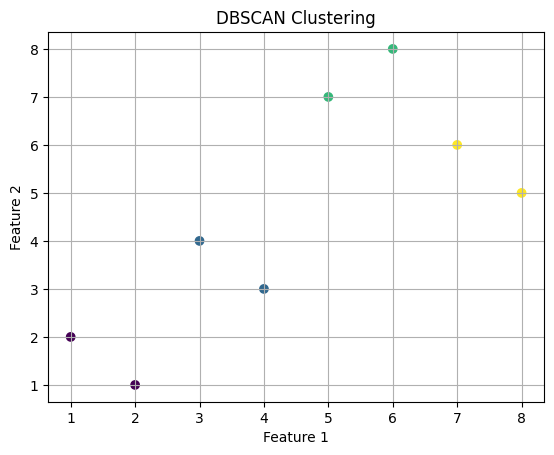

In [16]:
# DENSITY-BASED CLUSTERING (DBSCAN)
# DBSCAN imported only when needed
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=2)  #eps means maximum distance allowed between neighboring points. and min_samples means Minimum number of nearby points needed to form a dense region.
db_labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=db_labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()

In [21]:
# ASSOCIATION RULE LEARNING
"""
Market Basket Analysis
- Discover frequent itemsets
- Generate association rules
"""

#Each set represents one coustomer's purchase.
transactions = [ 
    {"Bread", "Milk", "Egg", "Butter", "Salt", "Apple"}, 
    {"Bread", "Milk", "Egg", "Apple"}, 
    {"Bread", "Milk", "Butter", "Apple"}, 
    {"Milk", "Egg", "Butter", "Apple"}, 
    {"Bread", "Egg", "Salt"}, 
    {"Bread", "Milk", "Egg", "Apple"}
]
print(transactions)

[{'Salt', 'Bread', 'Egg', 'Apple', 'Milk', 'Butter'}, {'Bread', 'Egg', 'Apple', 'Milk'}, {'Bread', 'Butter', 'Apple', 'Milk'}, {'Egg', 'Butter', 'Apple', 'Milk'}, {'Bread', 'Egg', 'Salt'}, {'Bread', 'Egg', 'Apple', 'Milk'}]


In [23]:
# To print transactions in dataframe
# Pandas is required only at this stage
import pandas as pd

# Convert transactions into a DataFrame (one-hot encoding style)
items = sorted(set().union(*transactions))
data = []

for t in transactions: 
    row = {item: (1 if item in t else 0) for item in items} 
    data.append(row)
    
df = pd.DataFrame(data)
df.index = range(1, len(df) + 1)
df.index.name = "Transaction"
print(df)

             Apple  Bread  Butter  Egg  Milk  Salt
Transaction                                       
1                1      1       1    1     1     1
2                1      1       0    1     1     0
3                1      1       1    0     1     0
4                1      0       1    1     1     0
5                0      1       0    1     0     1
6                1      1       0    1     1     0


In [24]:
# SUPPORT AND CONFIDENCE FUNCTIONS
def support(itemset, transactions): 
    return sum(1 for t in transactions if itemset.issubset(t)) / len(transactions)

def confidence(X, Y, transactions): 
    return support(X.union(Y), transactions) / support(X, transactions)

# Example rules
print("Support(Bread):", support({"Bread"}, transactions))
print("Confidence(Bread → Milk):", confidence({"Bread"}, {"Milk"}, transactions))
print("Confidence(Bread, Milk → Egg):", confidence({"Bread", "Milk"}, {"Egg"}, transactions))

Support(Bread): 0.8333333333333334
Confidence(Bread → Milk): 0.7999999999999999
Confidence(Bread, Milk → Egg): 0.75
